In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'/content/student_performance_dataset.csv')
df.head()

,student_id,gender,age,department,semester,study_hours_per_day,attendance_percentage,sleep_hours_per_day,backlogs,extracurricular_activity,internet_access_at_home,part_time_job,family_income_level,cgpa,placed
0,STU1000,Male,20,Mechanical,5,2.3,83.1,7.4,1,Yes,Yes,Yes,High,7.58,Yes
1,STU1001,Female,21,Computer Science,2,6.3,66.2,6.8,2,No,Yes,No,High,8.04,Yes
2,STU1002,Female,19,IT,7,3.4,100.0,4.6,0,Yes,Yes,No,Low,8.73,Yes
3,STU1003,Female,20,Mechanical,4,6.7,74.0,8.2,1,Yes,Yes,No,Low,9.69,Yes
4,STU1004,Male,20,Computer Science,5,5.6,74.3,6.7,2,Yes,Yes,Yes,Medium,7.68,No


In [3]:
df.isnull()
df.isnull().sum()

,0
student_id,0
gender,0
age,0
department,0
semester,0
study_hours_per_day,0
attendance_percentage,0
sleep_hours_per_day,0
backlogs,0
extracurricular_activity,0


In [4]:
df.shape

(3000, 15)

In [5]:
df.describe()

,age,semester,study_hours_per_day,attendance_percentage,sleep_hours_per_day,backlogs,cgpa
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,19.823000,4.549333,4.007433,78.078633,6.520767,0.728000,7.913240
std,1.184119,2.295936,1.904862,11.677391,1.196256,0.787119,1.043578
min,18.000000,1.000000,0.000000,38.100000,3.000000,0.000000,4.000000
25%,19.000000,3.000000,2.700000,70.200000,5.700000,0.000000,7.210000
50%,20.000000,5.000000,4.000000,78.200000,6.500000,1.000000,7.920000
75%,21.000000,7.000000,5.300000,86.300000,7.300000,1.000000,8.670000
max,22.000000,8.000000,10.300000,100.000000,10.000000,4.000000,10.000000


In [6]:
df.value_counts(['department','cgpa'])


department        cgpa 
Computer Science  10.00    29
Electronics       10.00    14
Computer Science  7.85      8
Mechanical        8.27      7
Computer Science  7.14      7
                           ..
Mechanical        9.53      1
                  9.55      1
                  9.28      1
Civil             6.50      1
                  6.51      1
Name: count, Length: 1589, dtype: int64

In [7]:
df[df['cgpa'] == 10.00]['department'].value_counts()

,count
department,
Computer Science,29
Electronics,14
IT,7
Mechanical,7
Electrical,7
Civil,4


# here i found department and semester wise no. of students who got 10 cgpa

In [8]:
df[df['cgpa'] == 10.00].groupby(['department', 'semester']).size().reset_index(name='count')

,department,semester,count
0,Civil,4,1
1,Civil,6,2
2,Civil,8,1
3,Computer Science,2,4
4,Computer Science,3,4
5,Computer Science,4,5
6,Computer Science,5,3
7,Computer Science,6,5
8,Computer Science,7,3
9,Computer Science,8,5


In [9]:
df.value_counts(['department'])

,count
department,
Computer Science,927
Electronics,634
Mechanical,463
IT,415
Electrical,282
Civil,279


In [10]:
df[(df['cgpa'] == 10.00) & (df['placed'] == 'Yes')].groupby(['department', 'semester', 'placed']).size().reset_index(name='count')

,department,semester,placed,count
0,Civil,4,Yes,1
1,Civil,6,Yes,2
2,Computer Science,2,Yes,4
3,Computer Science,3,Yes,4
4,Computer Science,4,Yes,5
5,Computer Science,5,Yes,3
6,Computer Science,6,Yes,5
7,Computer Science,7,Yes,3
8,Computer Science,8,Yes,5
9,Electrical,3,Yes,3


In [11]:
placed_counts = df['placed'].value_counts()
total_students = placed_counts.sum()
placed_students = placed_counts.get('Yes', 0)

placement_percentage = (placed_students / total_students) * 100
print(f"Placement Percentage Rate: {placement_percentage:.2f}%")

Placement Percentage Rate: 71.50%


# visualisation of data

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df.columns

Index(['student_id', 'gender', 'age', 'department', 'semester',
       'study_hours_per_day', 'attendance_percentage', 'sleep_hours_per_day',
       'backlogs', 'extracurricular_activity', 'internet_access_at_home',
       'part_time_job', 'family_income_level', 'cgpa', 'placed'],
      dtype='object')

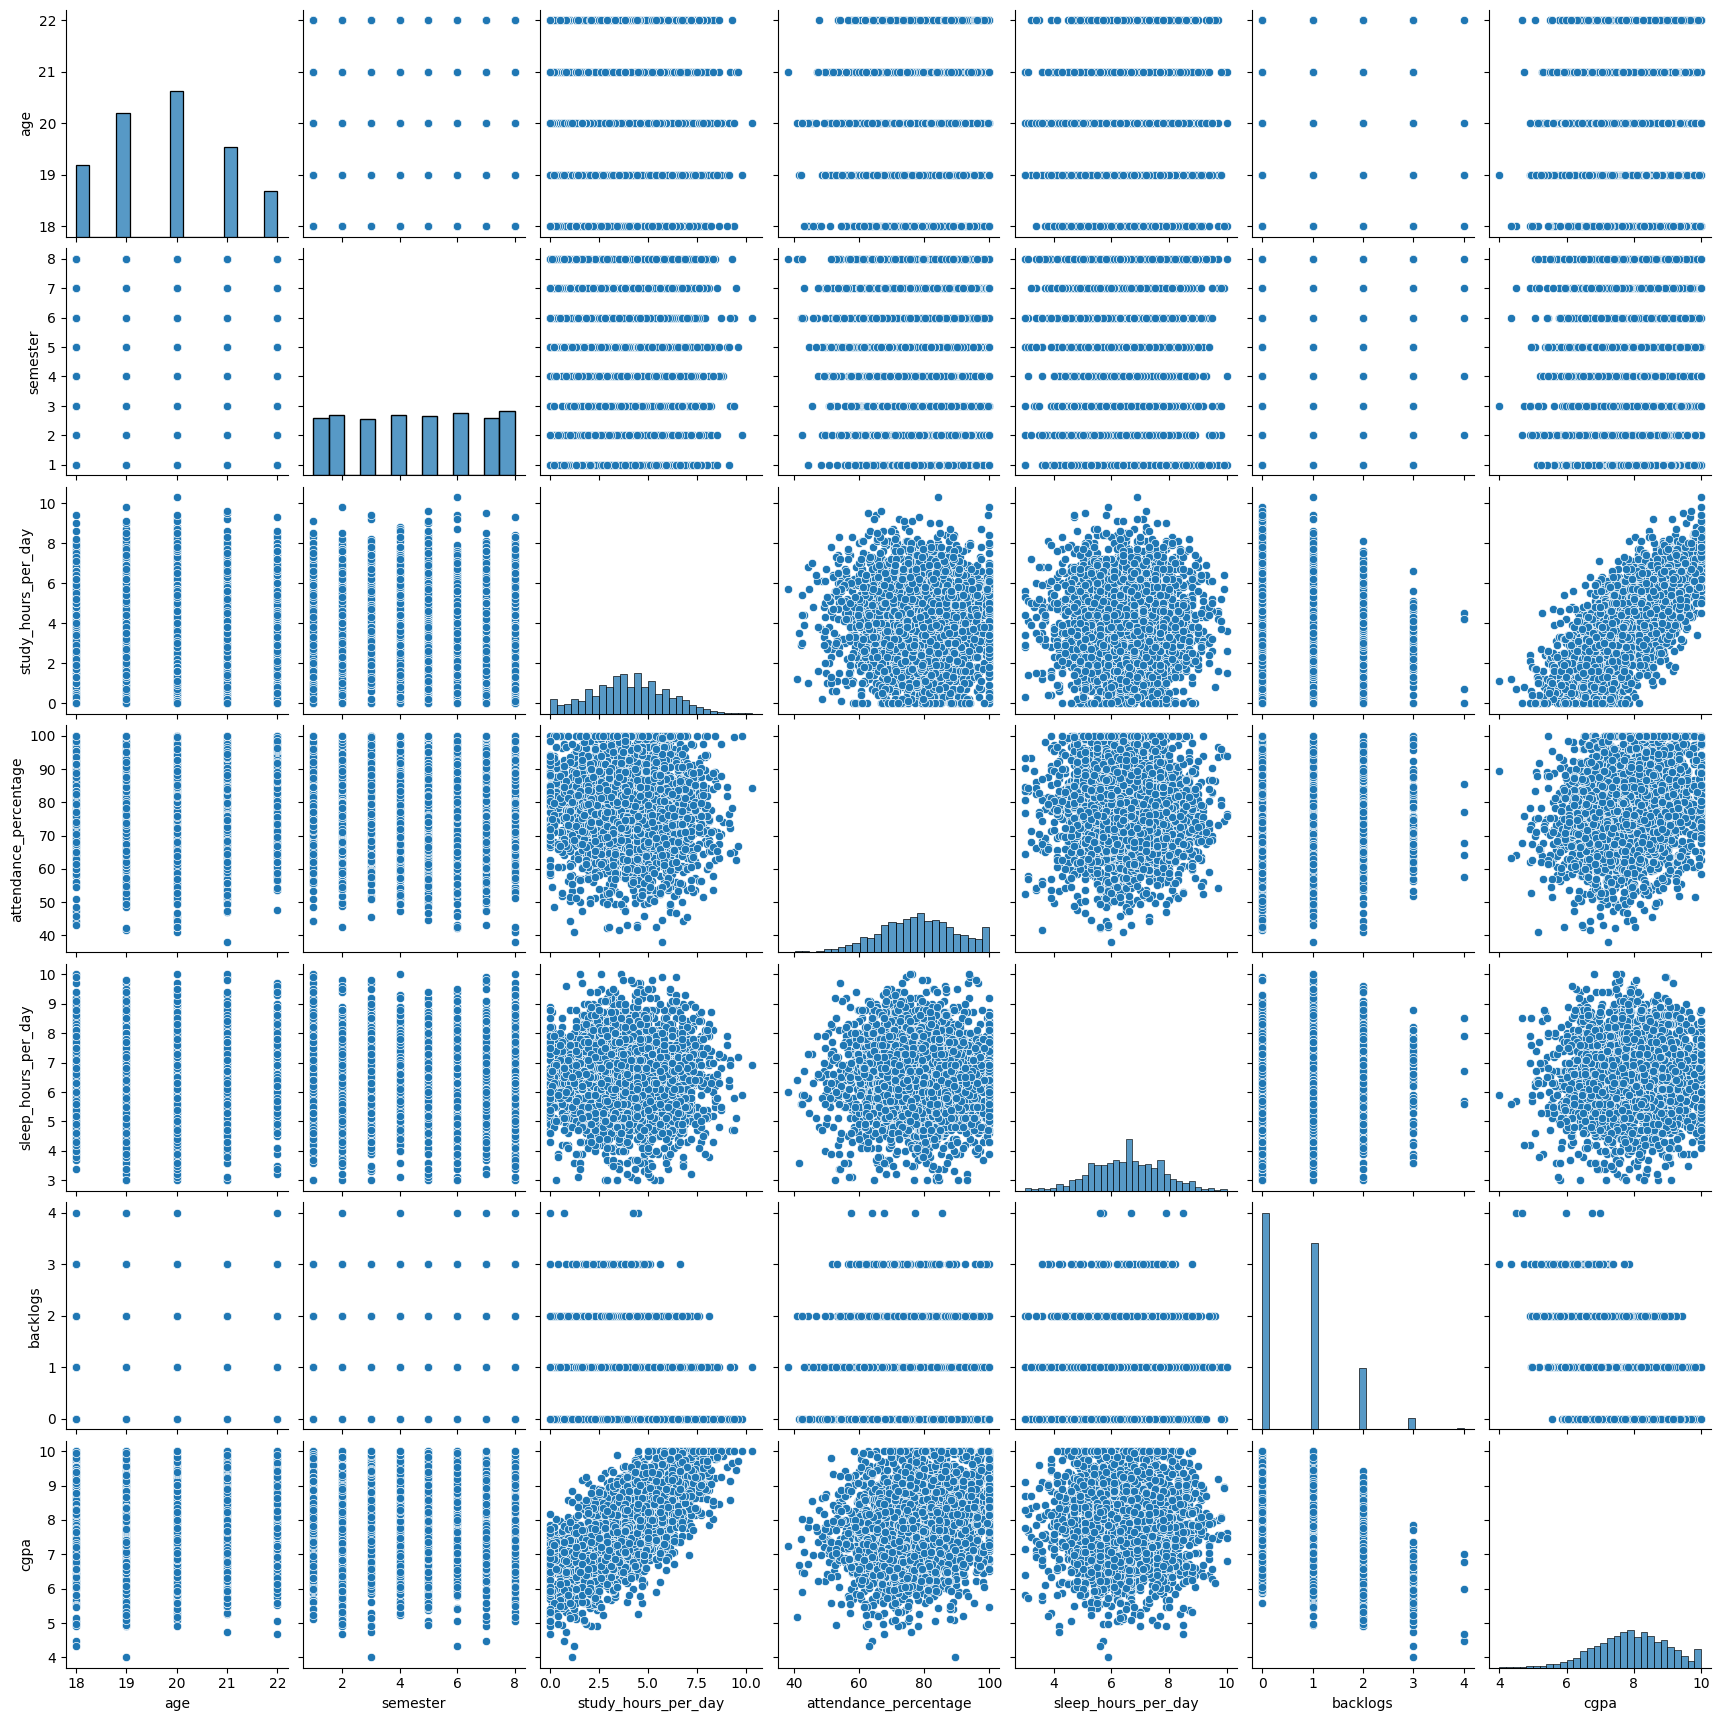

In [14]:
sns.pairplot(data = df)

In [15]:
df['backlogs'].value_counts().sort_index()

,count
backlogs,
0,1361
1,1176
2,386
3,72
4,5


<Axes: xlabel='backlogs', ylabel='Count'>

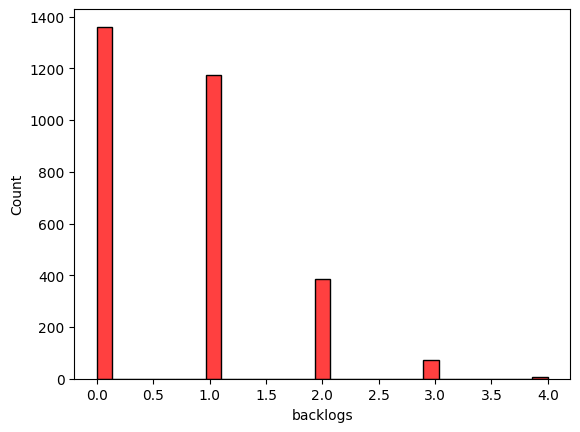

In [16]:
sns.histplot(data = df,x='backlogs',
color='red')


 notice that 3 or 4 backlogs are less

In [17]:
df['cgpa'].value_counts().sort_index()

,count
cgpa,
4.00,1
4.34,1
4.48,1
4.68,1
4.74,1
...,...
9.94,2
9.96,3
9.97,1


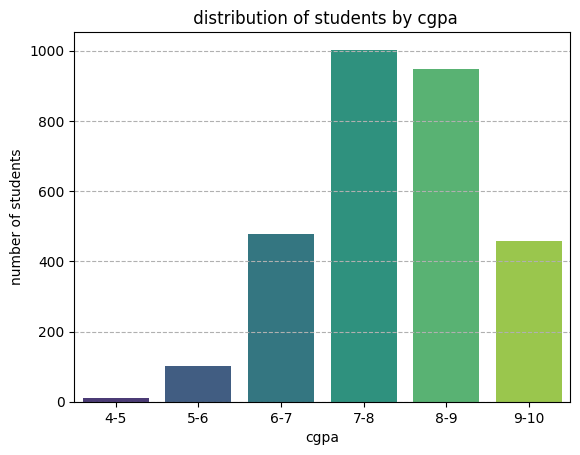

In [18]:
sns.color_palette("viridis", as_cmap=True)

bar = [4,5,6,7,8,9,10]
labels = ['4-5','5-6','6-7','7-8','8-9','9-10']
plt.grid(axis='y', linestyle='--')
df['cgpa_range'] = pd.cut(df['cgpa'], bins=bar, labels=labels, include_lowest=True)
sns.countplot(data = df,x= 'cgpa_range',hue = 'cgpa_range',palette='viridis')
plt.xlabel('cgpa')
plt.ylabel('number of students')
plt.title(' distribution of students by cgpa')
plt.show()
plt.figsize = (16,12)
plt.show()


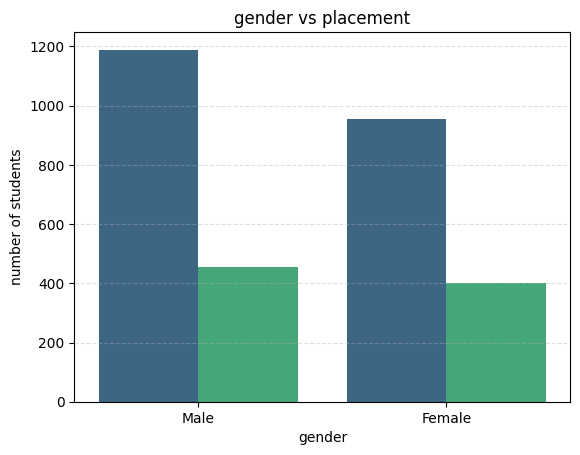

In [21]:
sns.countplot(data = df , x='gender',hue= 'placed',palette='viridis',
legend=False    )
plt.title('gender vs placement')
plt.xlabel('gender')
plt.ylabel('number of students')
plt.grid(axis='y',linestyle ='--',alpha= 0.4)
plt.show()


### Placement Rate by Department and Gender

In [22]:
placement_by_dept_gender = df.groupby(['department', 'gender'])['placed'].value_counts(normalize=True).unstack()
placement_by_dept_gender['Placed_Percentage'] = placement_by_dept_gender.get('Yes', 0) * 100
display(placement_by_dept_gender[['Placed_Percentage']].sort_values(by='Placed_Percentage', ascending=False))

,placed,Placed_Percentage
department,gender,
Civil,Male,74.666667
Electrical,Male,74.468085
Mechanical,Male,74.444444
IT,Female,73.762376
Computer Science,Female,72.380952
Mechanical,Female,72.020725
Computer Science,Male,71.400394
IT,Male,71.361502
Electronics,Male,70.994475


### Heatmap of Placement Rate by Department and Gender

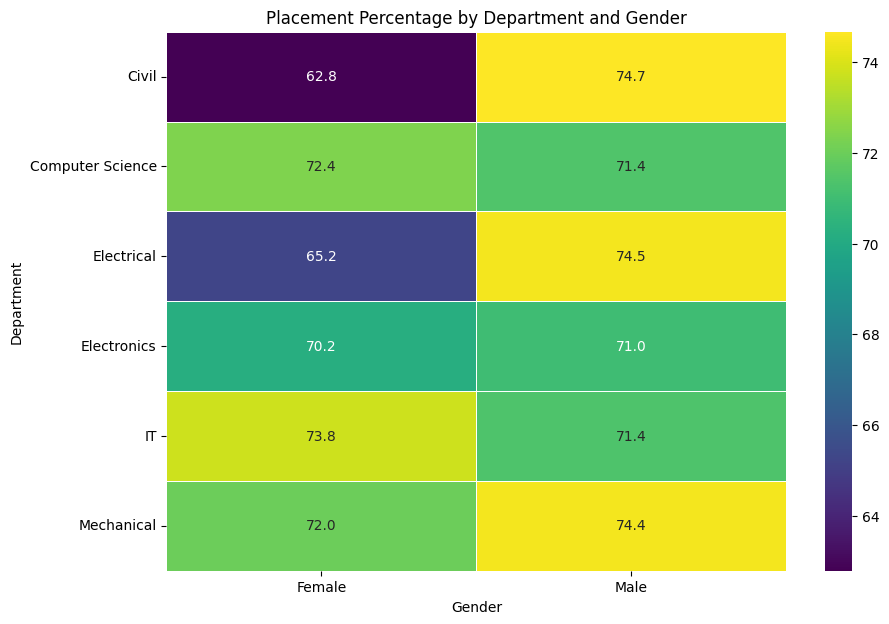

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

placement_heatmap_data = placement_by_dept_gender.reset_index().pivot(index='department', columns='gender', values='Placed_Percentage')

plt.figure(figsize=(10, 7))
sns.heatmap(placement_heatmap_data, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title('Placement Percentage by Department and Gender')
plt.xlabel('Gender')
plt.ylabel('Department')
plt.show()

## This heatmap shows that male placement rates are generally higher across departments, with the largest gender gap in Civil Engineering which is 11.9% , while Computer Science and IT show slightly higher placement rates for females